## PydanticAI 구조화된 출력

- [구조화된 출력 공식 문서](https://ai.pydantic.dev/output/)

**실습 목표:**

1. **구조화된 출력(Structured Output)** 으로 AI 응답을 Pydantic 모델로 받을 수 있다
2. **Field 파라미터와 타입 제약조건** 으로 응답 형식을 세밀하게 제어할 수 있다
3. **`@agent.output_validator`** 로 출력 결과를 검증하고 자동 재시도할 수 있다
4. 구조화된 출력을 활용하여 **텍스트 데이터 전처리** (분류, 마스킹, 표준화)를 수행할 수 있다

**사전 요구:** `1_PydanticAI_기본_호출.ipynb` 실습 완료

### 환경 설정

실습에 필요한 패키지를 설치하고, API 키를 설정합니다.

In [2]:
# ========================================
# 필요한 라이브러리를 불러옵니다
# ========================================

import os
import time
import platform
from pprint import pprint
from typing import List, Literal, Optional

import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from pydantic_ai import Agent, ModelRetry
from pydantic_ai.models.google import GoogleModelSettings

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# .env 파일에서 API 키 로드
load_dotenv()
api_key = os.getenv('GEMINI_API_KEY')
gemini_model = os.getenv('GEMINI_MODEL', 'gemini-3.1-flash-lite-preview')

# PydanticAI는 GEMINI_API_KEY 환경변수를 자동으로 인식합니다
# 모델 ID 형식: 'google-gla:{모델명}'
model_id = f'google-gla:{gemini_model}'

# API 키 유효성 검사
api_key_valid = api_key and 'YOUR_API_KEY' not in api_key
print(f"API 키 설정 확인: {'O' if api_key_valid else 'X'}")
if not api_key_valid:
    print("[주의] .env 파일에서 GEMINI_API_KEY를 실제 API 키로 설정해주세요!")
print(f"모델 확인: {model_id}")

# API 호출 간격 (초) - 무료 플랜에 맞게 조정
API_DELAY = 3

API 키 설정 확인: O
모델 확인: google-gla:gemini-3.1-flash-lite-preview


### 1. 구조화된 출력 (Structured Output)

**(1) 구조화된 출력이란?**

PydanticAI의 **가장 강력한 기능** 입니다.

AI 응답은 기본적으로 **항상 문자열** 입니다.
여기서 도시 이름, 인구 숫자를 따로 꺼내려면 개발자가 직접 파싱 코드를 작성해야 합니다.

**구조화된 출력** 은 Python 클래스로 **"AI가 이 형식에 맞춰 대답해야 한다"** 는 양식을 미리 정의하는 것입니다.

| 구분 | 일반 응답 | 구조화된 출력 |
|------|----------|-------------|
| **응답 형태** | `"서울의 인구는 약 950만 명입니다."` | `CityInfo(city='서울', population=9500000)` |
| **데이터 접근** | 정규식/파싱 코드 직접 작성 | `result.output.city` 로 바로 접근 |
| **타입 검증** | 숫자인지, 문자인지 수동 확인 | 자동으로 타입 검증 |
| **형식 오류** | 개발자가 직접 재시도 로직 작성 | 검증 실패 시 자동 재시도 |

**(2) 사용 방법**

Pydantic의 `BaseModel`로 응답 양식을 정의하고, `output_type`에 지정하면 됩니다.

```python
from pydantic import BaseModel, Field

# 1단계: 응답 양식 정의
class CityInfo(BaseModel):
    city: str = Field(description="도시 이름")
    population: int = Field(description="인구 수")

# 2단계: Agent에 output_type 지정
agent = Agent(model_id, output_type=CityInfo)

# 3단계: 실행 => Python 객체로 반환
result = await agent.run("서울의 인구를 알려줘")
result.output.city        # '서울'
result.output.population  # 9500000
```

**(3) 동작 원리**

개발자가 프롬프트에 "이런 형식으로 답해줘"라고 직접 쓸 필요가 없습니다.
`output_type`에 `BaseModel` 클래스를 지정하면, PydanticAI가 알아서 처리합니다.

![구조화된 출력 동작 흐름](images/structured_output_flow.png)

| 단계 | 내용 |
|------|------|
| **1. 스키마 변환** | `BaseModel` => JSON Schema로 자동 변환하여 모델에 전달 |
| **2. AI 응답** | 모델이 JSON Schema에 맞춰 응답 생성 |
| **3. 자동 검증** | Pydantic이 응답을 검증 => 실패 시 자동 재시도 |
| **4. 커스텀 검증** | `@agent.output_validator`로 추가 검증 가능 |

퓨샷 프롬프팅은 그렇게 응답할 확률을 높여주는 거고, 구조화된 출력은 그 형식을 100%로 강제하는 느낌일까요?
퓨샷 프롬프팅 개념 들어가 있음 -> 응답 스키마 구조를 CONTEXT로 전달해주고!
강제를 하도록 llm 출력 부분에서 토큰 선별에 있어 <-- 스키마에 맞게끔 토큰 후보를 선별하는 그런 알고리즘 적용

**Field 파라미터와 타입 제약조건**

`Field()`와 Python 타입 힌트를 조합하면 AI 응답에 **세부 조건** 을 강제할 수 있습니다.

**Field() 옵션:**

| 파라미터 | 용도 | 예시 |
|----------|------|------|
| `description` | AI에게 이 필드가 뭔지 알려주기 | `Field(description="영화 제목")` |
| `min_length` / `max_length` | 문자열 길이 제한 | `Field(min_length=5, max_length=100)` |
| `ge` / `le` | 숫자 범위 (이상/이하) | `Field(ge=1, le=10)` |
| `gt` / `lt` | 숫자 범위 (초과/미만) | `Field(gt=0, lt=100)` |
| `pattern` | 정규식 패턴 강제 | `Field(pattern=r"^\d{3}-\d{4}$")` |
| `default` | 기본값 지정 | `Field(default="없음")` |
| `examples` | 예시값 제공 | `Field(examples=["서울", "부산"])` |

**타입 힌트로 거는 제약조건 (자주 사용):**

| 타입 | 용도 | 예시 |
|------|------|------|
| `Literal["A", "B"]` | 지정된 값 중 하나만 허용 (선택지 고정) | `sentiment: Literal["긍정", "부정", "중립"]` |
| `list[str]` | 문자열 리스트 | `keywords: list[str]` |
| `Optional[str]` | 값이 없을 수도 있음 (`None` 허용) | `subtitle: Optional[str] = None` |
| `int` / `float` / `bool` | 기본 타입 강제 | `score: int`, `is_valid: bool` |

```python
from typing import Literal, Optional

class ReviewAnalysis(BaseModel):
    sentiment: Literal["긍정", "부정", "중립"]           # 3개 중 하나만 허용
    confidence: float = Field(ge=0.0, le=1.0)           # 0~1 사이 실수
    keywords: list[str] = Field(min_length=1)            # 1개 이상의 키워드
    summary: str = Field(min_length=10, max_length=200)  # 길이 제한
    is_recommended: bool                                  # True/False만 허용
    warning: Optional[str] = None                         # 없을 수도 있는 필드
```

> **핵심:** 이 제약조건들은 **두 가지 역할** 을 동시에 합니다.
> 1. JSON Schema에 포함되어 **AI가 응답을 생성할 때 참고** 합니다 (예: "긍정/부정/중립 중 하나를 넣어야겠구나")
> 2. 응답이 돌아온 뒤 **Pydantic이 실제로 조건을 만족하는지 검증** 합니다. 검증 실패 시 자동으로 재시도합니다.

**실습**
- `MovieReview` 스키마를 정의하고, AI에게 영화 리뷰를 구조화된 형식으로 받습니다.
- `Field`의 다양한 제약조건(`min_length`, `ge`, `le` 등)이 실제로 지켜지는지 확인합니다.

In [2]:
# 다양한 Field 제약조건을 활용한 출력 스키마 정의
class MovieReview(BaseModel):
    title: str = Field(
        description="영화 제목",
        min_length=1, max_length=50       # 1~50글자 사이
    )
    score: int = Field(
        description="평점 (1~5점)",
        ge=1, le=5                         # 1점 ~ 5점 사이만 허용
    )
    summary: str = Field(
        description="한 줄 요약",
        min_length=10, max_length=200      # 최소 10글자 이상
    )
    recommend: bool = Field(
        description="추천 여부 (True/False)"
    )
    tags: list[str] = Field(
        description="장르 태그 목록 (1~5개)",
        min_length=1, max_length=5         # 태그 1~5개
    )

# BaseModel이 생성하는 JSON Schema 확인
# - 이 스키마가 모델에 tool call로 주입되어 응답 형식을 강제합니다
print("=" * 60)
print("[MovieReview의 JSON Schema]")
print("=" * 60)
pprint(MovieReview.model_json_schema())

[MovieReview의 JSON Schema]
{'properties': {'recommend': {'description': '추천 여부 (True/False)',
                              'title': 'Recommend',
                              'type': 'boolean'},
                'score': {'description': '평점 (1~5점)',
                          'maximum': 5,
                          'minimum': 1,
                          'title': 'Score',
                          'type': 'integer'},
                'summary': {'description': '한 줄 요약',
                            'maxLength': 200,
                            'minLength': 10,
                            'title': 'Summary',
                            'type': 'string'},
                'tags': {'description': '장르 태그 목록 (1~5개)',
                         'items': {'type': 'string'},
                         'maxItems': 5,
                         'minItems': 1,
                         'title': 'Tags',
                         'type': 'array'},
                'title': {'description': '영화 제목',
             

# 나중에 텍스트 데이터를 수집할때 api를 사용하지 않고 제미나이를 사용해서 오늘 배운 방식으로 수집할 수 있는걸까요?

# 비추천!! 가능은한데!
# 신뢰성없을 수 있음!
# 너무나 명확한 명제
# 지구는 둥글다! 이런한 데이터를 수집할때도 되는데

# 영화 리뷰나 영화 줄거리를 llM을 토대로 데이터를 수집! (굉장히 위험!)
# 거짓말 할 수 있음!!


<!-- 사용자가 베이스 모델로 스키마를 만든 다음에 Agent를 불러서 답변을 받는 과정이었던 것인가요..? -->

In [3]:
# Agent 생성 - output_type에 스키마 지정
review_agent = Agent(
    model_id,
    output_type=MovieReview, #우리가 설계한 응답 스키마를 넣어줌!!
    system_prompt="영화 리뷰를 분석하는 전문가입니다.",
    retries=3 #응답 제약조건이 만족하지 못할 경우 최대 재시도 횟수 지정!!!
)

# 실행
result = await review_agent.run(
    "영화 '인터스텔라'에 대해 리뷰해주세요.",
    model_settings=GoogleModelSettings(temperature=0.3)
)

# 구조화된 결과 출력
output = result.output
pprint(output)
print()
print(f"제목: {output.title}")
print(f"평점: {'★' * output.score}{'☆' * (5 - output.score)} ({output.score}/5)")
print(f"추천: {'O' if output.recommend else 'X'}")
print(f"태그: {', '.join(output.tags)}")
print(f"요약: {output.summary}")

# Field 제약조건이 실제로 지켜졌는지 확인
print()
print("=" * 50)
print("[Field 제약조건 검증 결과]")
print("=" * 50)
print(f"  title 길이: {len(output.title)}자 (1~50 허용)")
print(f"  score 범위: {output.score} (1~5 허용)")
print(f"  summary 길이: {len(output.summary)}자 (10~200 허용)")
print(f"  tags 개수: {len(output.tags)}개 (1~5 허용)")

MovieReview(title='인터스텔라', score=5, summary='광활한 우주를 배경으로 한 압도적인 영상미와 가슴 뭉클한 가족애가 완벽하게 조화된 SF 걸작.', recommend=True, tags=['SF', '드라마', '우주', '명작', '감동'])

제목: 인터스텔라
평점: ★★★★★ (5/5)
추천: O
태그: SF, 드라마, 우주, 명작, 감동
요약: 광활한 우주를 배경으로 한 압도적인 영상미와 가슴 뭉클한 가족애가 완벽하게 조화된 SF 걸작.

[Field 제약조건 검증 결과]
  title 길이: 5자 (1~50 허용)
  score 범위: 5 (1~5 허용)
  summary 길이: 52자 (10~200 허용)
  tags 개수: 5개 (1~5 허용)


# 비정형 데이터를 --> 정형화 시킬 수 있다!!! 
# 비정형 데이터 분석의 핵심기술!!!


이 구조화된 응답을 사용하는 이유가 다른 에이전트한테 넘겨주기 위해서의 이유가 더 클까요? <-- 이 목적으로 활용
사람이 보기위한 목적이라기 보다는 <-- 사람을 위한 목적이 있음!
# 분석 하기 편하려고!

llm은 대충 정보를 구조화 시키 않고 넣어줘도 잘 분석하고 이해하고 처리!!
사람은 구조화되야 분석하기 용이함!!


AI 가 웹으로 가서 텍스트 데이터를 가져와서 -> 구조화된 출력을 한다 로 이해하면 될까요?
(웹으로 가서???)


### 2. `@agent.output_validator` - 출력 검증

AI의 응답이 **조건에 맞는지 자동으로 검증** 하고, 맞지 않으면 **모델에게 다시 요청** 합니다.

```
AI 응답 생성 => output_validator 검증 => 통과 시 반환 / 실패 시 ModelRetry로 재시도
```

**2단계 검증 구조:**

| 단계 | 정의 방법 | 검증 내용 | 예시 |
|------|----------|----------|------|
| **1단계** Pydantic 자동 검증 | `Field(ge=1, le=5)` 등 | 타입, 범위, 길이, 패턴 등 형식 검증 | score가 6이면 자동 재시도 |
| **2단계** output_validator | `@agent.output_validator` | 필드 간 논리적 일관성 등 커스텀 검증 | 긍정인데 score < 3이면 재시도 |

> **정리:**
> - `Field()` 제약조건만으로 충분하면 `output_validator`는 불필요합니다
> - 여러 필드 간의 **논리적 관계** 를 검증해야 할 때만 `output_validator`를 추가합니다

@agent.output_valiator 설계 안하더라도 
- 출력 설계한 것에 맞지 않으면 재시도 (재시도 이유도 프롬프트에 들어가서 재시도 요청)
- 1개의 필드에 대한 제약조건을 실패했을 때 자동으로 실행

@agent.output_valiator 설계
- 여러 필드간의 논리적 관계를 검증해야할 때

**실습 (1)**
- 영화 리뷰 분석 Agent에 `output_validator`를 추가합니다.
- 감정(긍정/부정)과 점수의 일관성을 자동으로 검증하고, 불일치 시 재시도합니다.

In [4]:
# 감정-점수 일관성 검증이 필요한 출력 스키마
class SentimentReview(BaseModel):
    sentiment: Literal["긍정", "부정"] = Field(description="감정 분류")
    score: int = Field(ge=1, le=5, description="평점 (1~5점)")
    summary: str = Field(min_length=10, max_length=200, description="한 줄 요약")


# Agent 생성
validator_agent = Agent(
    model_id,
    output_type=SentimentReview,
    system_prompt="영화 리뷰를 분석하는 전문가입니다. 감정과 점수를 평가해주세요."
)


# output_validator: 감정과 점수의 논리적 일관성 검증
# - 1단계(Field 제약조건) 통과 후 실행됩니다
# - ModelRetry를 raise하면 모델에게 사유를 전달하고 재시도합니다
@validator_agent.output_validator
def validate_consistency(ctx, output: SentimentReview) -> SentimentReview:
    """감정과 점수의 일관성을 검증합니다."""
    # 긍정인데 점수가 낮으면 재시도
    if output.sentiment == "긍정" and output.score < 4:
        raise ModelRetry(
            f"감정이 '긍정'이면 점수는 4점 이상이어야 합니다. 현재: {output.score}점. 점수를 조정해주세요."
        )
    # 부정인데 점수가 높으면 재시도
    if output.sentiment == "부정" and output.score > 3:
        raise ModelRetry(
            f"감정이 '부정'이면 점수는 3점 이하여야 합니다. 현재: {output.score}점. 점수를 조정해주세요."
        )
    return output


# 실행 - 긍정적인 리뷰
result = await validator_agent.run(
    "재밌는것 같기도하고!",
    model_settings=GoogleModelSettings(temperature=0.3)
)

output = result.output
print(f"감정: {output.sentiment}")
print(f"점수: {'★' * output.score}{'☆' * (5 - output.score)} ({output.score}/5)")
print(f"요약: {output.summary}")

감정: 긍정
점수: ★★★★☆ (4/5)
요약: 재미를 느끼기 시작한 긍정적인 반응입니다.


**실습 (2)**
- 위 실행에서 AI가 몇 번 시도했고, 왜 재시도했는지 추적합니다.
- `result.all_messages()`로 전체 대화 기록을 순회하면 검증 실패 과정을 확인할 수 있습니다.

**`all_messages()` vs `new_messages()` 차이:**

| 메서드 | 반환 범위 | 용도 |
|--------|----------|------|
| `all_messages()` | 시스템 프롬프트 + 이전 대화 + 현재 턴 **전체** | 재시도 과정 추적, 디버깅 |
| `new_messages()` | 현재 턴에서 **새로 생긴 메시지만** | 멀티턴 대화에서 `message_history`로 전달 |

In [ ]:
print(result.all_messages()) #이전 대화 포함
print(result.output) #최종 응답 결과 텍스트 형태 
print(result.new_messages()) #현재 턴에 새로 생긴 메시지
print(result.usage()) #토큰 사용량

sentiment='긍정' score=4 summary='재미를 느끼기 시작한 긍정적인 반응입니다.'
[ModelRequest(parts=[SystemPromptPart(content='영화 리뷰를 분석하는 전문가입니다. 감정과 점수를 평가해주세요.', timestamp=datetime.datetime(2026, 4, 3, 6, 41, 41, 597900, tzinfo=datetime.timezone.utc)), UserPromptPart(content='재밌는것 같기도하고!', timestamp=datetime.datetime(2026, 4, 3, 6, 41, 41, 597900, tzinfo=datetime.timezone.utc))], timestamp=datetime.datetime(2026, 4, 3, 6, 41, 41, 597900, tzinfo=datetime.timezone.utc), run_id='65978b7e-4dac-4537-8c77-14933cf2afa2'), ModelResponse(parts=[ToolCallPart(tool_name='final_result', args={'sentiment': '긍정', 'summary': '재미와 아쉬움이 공존하는 평범한 감상입니다.', 'score': 3}, tool_call_id='ofbsm0gt', provider_name='google-gla', provider_details={'thought_signature': 'EjQKMgG+Pvb7pkLYpeBEtQOR+MojJUxM/KK8sVJr0bhhrWIiZA6UvroOuiVXt45UhuNFkB0O'})], usage=RequestUsage(input_tokens=160, output_tokens=43, details={'text_prompt_tokens': 160}), model_name='gemini-3.1-flash-lite-preview', timestamp=datetime.datetime(2026, 4, 3, 6, 41, 43, 556

In [ ]:
# 검증 과정 상세 추적 - AI의 시도 횟수와 재시도 사유 확인
result.all_messages()

[ModelRequest(parts=[SystemPromptPart(content='영화 리뷰를 분석하는 전문가입니다. 감정과 점수를 평가해주세요.', timestamp=datetime.datetime(2026, 4, 3, 6, 41, 41, 597900, tzinfo=datetime.timezone.utc)), UserPromptPart(content='재밌는것 같기도하고!', timestamp=datetime.datetime(2026, 4, 3, 6, 41, 41, 597900, tzinfo=datetime.timezone.utc))], timestamp=datetime.datetime(2026, 4, 3, 6, 41, 41, 597900, tzinfo=datetime.timezone.utc), run_id='65978b7e-4dac-4537-8c77-14933cf2afa2'),
 ModelResponse(parts=[ToolCallPart(tool_name='final_result', args={'sentiment': '긍정', 'summary': '재미와 아쉬움이 공존하는 평범한 감상입니다.', 'score': 3}, tool_call_id='ofbsm0gt', provider_name='google-gla', provider_details={'thought_signature': 'EjQKMgG+Pvb7pkLYpeBEtQOR+MojJUxM/KK8sVJr0bhhrWIiZA6UvroOuiVXt45UhuNFkB0O'})], usage=RequestUsage(input_tokens=160, output_tokens=43, details={'text_prompt_tokens': 160}), model_name='gemini-3.1-flash-lite-preview', timestamp=datetime.datetime(2026, 4, 3, 6, 41, 43, 556953, tzinfo=datetime.timezone.utc), provider_name='googl

In [11]:
# 검증 과정 상세 추적 - AI의 시도 횟수와 재시도 사유 확인
print("=" * 60)
print("[검증 과정 상세 추적]")
print("=" * 60)

attempt = 0
for msg in result.all_messages():
    kind = type(msg).__name__

    if kind == "ModelResponse":
        for part in msg.parts:
            part_type = type(part).__name__
            if part_type == "ToolCallPart":
                attempt += 1
                # tool call의 args에서 AI가 생성한 출력값 확인
                print(f"[시도 {attempt}] AI가 생성한 출력:")
                if isinstance(part.args, dict):
                    for k, v in part.args.items():
                        print(f"    {k}: {v}")
                else:
                    print(f"    {part.args}")

    elif kind == "ModelRequest":
        for part in msg.parts:
            part_type = type(part).__name__
            if part_type == "RetryPromptPart":
                # 검증 실패 => AI에게 전달된 재시도 메시지
                print(f"  => 검증 실패! 재시도 사유: {part.content}")
            elif part_type == "ToolReturnPart":
                content_str = str(part.content)
                if len(content_str) > 100:
                    content_str = content_str[:100] + "..."
                print(f"  => 검증 통과: {content_str}")

print("=" * 60)
if attempt > 1:
    print(f"총 {attempt}회 시도 (재시도 {attempt - 1}회 발생)")

[검증 과정 상세 추적]
[시도 1] AI가 생성한 출력:
    sentiment: 긍정
    summary: 재미와 아쉬움이 공존하는 평범한 감상입니다.
    score: 3
  => 검증 실패! 재시도 사유: 감정이 '긍정'이면 점수는 4점 이상이어야 합니다. 현재: 3점. 점수를 조정해주세요.
[시도 2] AI가 생성한 출력:
    score: 4
    summary: 재미를 느끼기 시작한 긍정적인 반응입니다.
    sentiment: 긍정
  => 검증 통과: Final result processed.
총 2회 시도 (재시도 1회 발생)


### 3. 고객 문의 데이터 전처리

#### LLM 응답 스키마 설계 가이드

**스키마 설계 프로세스**

**1. 비즈니스 질문부터 시작**

Q: LLM으로부터 무엇을 얻고 싶은가?\
A: 고객 문의를 자동 분류하고, 우선순위를 정하고, 감정을 파악하고 싶다

**2. 필요한 정보 나열**

- 문의 유형: 환불? 배송? 상품?
- 긴급도: 낮음/보통/높음/긴급
- 고객 감정: 긍정/중립/부정
- 핵심 키워드: ["배송 지연", "환불 요청"]
- 주문번호: ORDER-12345 (있을 수도, 없을 수도)
- 권장 응답 가이드 : "배송 지연 사과 후 예상 도착일 안내"

**3. Pydantic 스키마 설계**

| 필드 | 타입 | 설명 | 제약조건 |
|------|------|------|----------|
| `category` | `Literal[...]` | 문의 유형 | 7가지 고정 값 |
| `urgency` | `Literal[...]` | 긴급도 | 4가지 고정 값 |
| `emotion` | `Literal[...]` | 감정 상태 | 3가지 고정 값 |
| `key_issues` | `List[str]` | 핵심 이슈 | `max_length=5` (최대 5개) |
| `order_number` | `Optional[str]` | 주문번호 | `default=None` (없으면 null) |
| `suggested_response` | `str` | 응답 가이드 | `max_length=200` (최대 200자) |

**설계 포인트:**
- **Literal** 사용: 선택지가 정해진 필드 => `Literal["a", "b", "c"]`로 허용 값을 직접 지정. Enum 클래스 정의 없이 간결하게 표현 가능
- **Optional** 사용: 없을 수 있는 정보 => `Optional[str]`로 null 허용
- **max_length**: 리스트 항목 수와 문자열 길이를 제한하여 토큰 절약
- **description에 분류 기준 포함**: Literal 필드의 각 값이 뭔지 `description`에 직접 기술하면, system_prompt에서 중복 설명이 불필요합니다. system_prompt는 **스키마로 표현 못 하는 지시** (역할, 행동 규칙)만 담습니다.

**4. PydanticAI에서 활용**

```python
# Agent 생성 시 output_type에 스키마를 지정하면
# PydanticAI가 자동으로 모델에 스키마를 전달하고, 응답을 파싱합니다
agent = Agent(model_id, output_type=CustomerInquiry, system_prompt="...")
result = await agent.run("고객 문의 내용")
result.output  # => CustomerInquiry 객체 (자동 파싱 완료)
```

**실습 (1)**
- 위 설계를 바탕으로 Pydantic 모델을 정의합니다.
- `Literal`, `Field`, `Optional` 등 타입 제약조건을 활용합니다.

In [12]:
# =============================================================================
#  고객 문의 데이터 전처리 스키마 정의
# =============================================================================

class CustomerInquiry(BaseModel):
    category: Literal["refund", "exchange", "delivery", "product", "technical", "complaint", "other"] = Field(
        description="문의 유형. refund: 환불, exchange: 교환, delivery: 배송 조회/지연/분실, product: 상품 정보/사양, technical: 로그인/결제/시스템 오류, complaint: 서비스 불만, other: 기타"
    )
    urgency: Literal["low", "medium", "high", "urgent"] = Field(
        description="긴급도. urgent: 즉시 처리 요구, high: 시간 압박 표현, medium: 일반 요청, low: 단순 문의"
    )
    emotion: Literal["positive", "neutral", "negative"] = Field(
        description="감정. positive: 감사/만족/칭찬, neutral: 담담한 문의, negative: 불만/실망/화남"
    )
    key_issues: List[str] = Field(
        description="핵심 이슈 (명사형 키워드로 추출)",
        max_length=5
    )
    order_number: Optional[str] = Field(
        default=None,
        description="주문번호 (ORDER-XXXXX 패턴에서 추출, 없으면 null)"
    )
    suggested_response: str = Field(
        description="상담원 권장 응답 방향 (1-2문장)",
        max_length=200
    )

print("고객 문의 분석 스키마 정의 완료")

# BaseModel이 생성하는 JSON Schema 확인
# - 이 스키마가 PydanticAI Agent의 output_type으로 전달되어 응답 형식을 강제합니다
print("=" * 60)
print("[CustomerInquiry의 JSON Schema]")
print("=" * 60)
pprint(CustomerInquiry.model_json_schema())

고객 문의 분석 스키마 정의 완료
[CustomerInquiry의 JSON Schema]
{'properties': {'category': {'description': '문의 유형. refund: 환불, exchange: 교환, '
                                            'delivery: 배송 조회/지연/분실, product: '
                                            '상품 정보/사양, technical: 로그인/결제/시스템 '
                                            '오류, complaint: 서비스 불만, other: 기타',
                             'enum': ['refund',
                                      'exchange',
                                      'delivery',
                                      'product',
                                      'technical',
                                      'complaint',
                                      'other'],
                             'title': 'Category',
                             'type': 'string'},
                'emotion': {'description': '감정. positive: 감사/만족/칭찬, neutral: '
                                           '담담한 문의, negative: 불만/실망/화남',
                            'enum':

**실습 (2)**
- 전처리할 고객 문의 샘플 데이터를 정의하고, `Agent(output_type=CustomerInquiry)`로 구조화된 출력을 강제합니다.
- `await agent.run()`으로 각 문의를 분석합니다.

In [ ]:
# =============================================================================
#  샘플 고객 문의 데이터
# =============================================================================

raw_inquiries = [
    "주문번호 ORDER-230415입니다. 환불 어떻게 하나요??? 급합니다ㅠㅠ 배송비 차감되나요??",
    "배송 언제 오나요...... 일주일 지났는데 추적도 안돼요ㅠㅠ 빨리 답변 부탁드립니다",
    "상품 불량입니다. 교환 가능한가요? 포장 찢어져서 왔고 제품에 스크래치 있어요. 010-1234-5678",
    "로그인이 안 됩니다... 비밀번호 재설정 눌러도 이메일 안 와요 도와주세요ㅠ",
    "감사합니다! 빠른 배송 덕분에 생일 선물 제때 받았어요 ^^ 포장도 깔끔하네요",
    "주문번호 ORDER-230512 / 노트북 파우치 색상 변경 가능할까요? 블랙 => 네이비로요",
]

# =============================================================================
#  시스템 프롬프트 정의
#  - 분류 기준은 스키마 description에 포함되어 있으므로
#    여기서는 스키마로 표현할 수 없는 행동 지시만 작성합니다
# =============================================================================

system_prompt = """
당신은 고객 서비스 데이터 분석 전문가입니다.
고객 문의를 받아 구조화된 형태로 분석하세요.
한국어 문의의 뉘앙스(존댓말, 이모티콘, 중복 표현)를 정확히 파악하세요.
"""

# =============================================================================
#  PydanticAI Agent 생성 및 고객 문의 전처리 실행
# =============================================================================

# Agent 생성 - output_type으로 구조화된 출력 강제
inquiry_agent = Agent(
    model_id,
    output_type=CustomerInquiry,
    system_prompt=system_prompt,
)

# 매개변수 설정 - 낮은 temperature로 일관된 분류 결과 유도
inquiry_settings = GoogleModelSettings(temperature=0.2)

print("고객 문의 데이터 전처리 시작...")
print("=" * 80)

# 처리된 문의 데이터를 저장할 리스트
processed_inquiries = []

# TODO : 각 고객 문의를 순회하며 PydanticAI Agent로 분석 구현
for i, inqury in enumerate(raw_inquiries, start=1) :
    print(f"[문의{i}]", inqury)

    # LLM에게 전달할 프롬프트 구성
    prompt = f"다음 고객 문의를 분석해주세요:\n{inqury}"

    # Agent 실행
    result = await inquiry_agent.run(prompt, model_settings=inquiry_settings)

    # 구조화된 응답 얻기
    output = result.output

    # 딕셔너리로 변환
    row = {'original_inqury': inqury, **output.model_dump()} #output.model_dump() 딕셔너리로 반환
    processed_inquiries.append(row)

# 전체 처리 결과 요약
print()
print("=" * 80)
print(f"총 {len(processed_inquiries)}개 문의 처리 완료")

고객 문의 데이터 전처리 시작...
[문의1] 주문번호 ORDER-230415입니다. 환불 어떻게 하나요??? 급합니다ㅠㅠ 배송비 차감되나요??
[문의2] 배송 언제 오나요...... 일주일 지났는데 추적도 안돼요ㅠㅠ 빨리 답변 부탁드립니다
[문의3] 상품 불량입니다. 교환 가능한가요? 포장 찢어져서 왔고 제품에 스크래치 있어요. 010-1234-5678
[문의4] 로그인이 안 됩니다... 비밀번호 재설정 눌러도 이메일 안 와요 도와주세요ㅠ
[문의5] 감사합니다! 빠른 배송 덕분에 생일 선물 제때 받았어요 ^^ 포장도 깔끔하네요
[문의6] 주문번호 ORDER-230512 / 노트북 파우치 색상 변경 가능할까요? 블랙 => 네이비로요

총 6개 문의 처리 완료


In [ ]:
output.model_dump() 

{'category': 'exchange',
 'urgency': 'medium',
 'emotion': 'neutral',
 'key_issues': ['주문 변경', '색상 변경', '노트북 파우치'],
 'order_number': 'ORDER-230512',
 'suggested_response': '주문하신 상품의 배송 상태를 확인한 후, 출고 전이라면 색상 변경 처리를 도와드리겠습니다. 잠시만 기다려 주세요.'}

In [14]:
pprint(processed_inquiries)

[{'category': 'refund',
  'emotion': 'negative',
  'key_issues': ['환불 방법', '배송비 차감'],
  'order_number': 'ORDER-230415',
  'original_inqury': '주문번호 ORDER-230415입니다. 환불 어떻게 하나요??? 급합니다ㅠㅠ 배송비 차감되나요??',
  'suggested_response': '환불 절차와 배송비 차감 정책을 안내해 드리고, 고객님의 불안함을 해소하기 위해 신속한 처리를 '
                        '약속드립니다.',
  'urgency': 'urgent'},
 {'category': 'delivery',
  'emotion': 'negative',
  'key_issues': ['배송 지연', '배송 추적 불가'],
  'order_number': None,
  'original_inqury': '배송 언제 오나요...... 일주일 지났는데 추적도 안돼요ㅠㅠ 빨리 답변 부탁드립니다',
  'suggested_response': '배송 지연으로 불편을 드려 죄송합니다. 현재 배송 상태를 즉시 확인하여 안내해 드리겠으니, '
                        '주문번호를 알려주시면 감사하겠습니다.',
  'urgency': 'high'},
 {'category': 'exchange',
  'emotion': 'negative',
  'key_issues': ['상품 불량', '포장 파손', '제품 스크래치'],
  'order_number': None,
  'original_inqury': '상품 불량입니다. 교환 가능한가요? 포장 찢어져서 왔고 제품에 스크래치 있어요. '
                     '010-1234-5678',
  'suggested_response': '상품 불량으로 불편을 드려 죄송합니다. 제품 상태 확인을 위해 사진을 요청드리고, 신속하게 교환 '
                  

**실습 (3)**
- 처리된 결과를 DataFrame 표 형태로 확인합니다.

In [1]:
import pandas as pd

# 처리 결과를 DataFrame으로 변환하여 표 형태로 확인
df_inquiries = pd.DataFrame(processed_inquiries)

print("=== 고객 문의 전처리 결과 (DataFrame) ===")
print()
display(df_inquiries)

NameError: name 'processed_inquiries' is not defined

In [ ]:
# 카테고리/긴급도/감정 한글 매핑
category_map = {
    "refund": "환불", "exchange": "교환", "delivery": "배송",
    "product": "상품", "technical": "기술", "complaint": "불만", "other": "기타"
}
urgency_map = {"low": "낮음", "medium": "보통", "high": "높음", "urgent": "긴급"}
emotion_map = {"positive": "긍정", "neutral": "중립", "negative": "부정"}

df_vis = df_inquiries.copy()
df_vis['category_kr'] = df_vis['category'].map(category_map)
df_vis['urgency_kr'] = df_vis['urgency'].map(urgency_map)
df_vis['emotion_kr'] = df_vis['emotion'].map(emotion_map)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) 문의 유형별 건수
sns.countplot(data=df_vis, y='category_kr', order=df_vis['category_kr'].value_counts().index,
              palette='Blues_d', ax=axes[0])
axes[0].set_title('문의 유형별 건수')
axes[0].set_xlabel('건수')
axes[0].set_ylabel('')

# 2) 긴급도 분포
urgency_order = ['낮음', '보통', '높음', '긴급']
urgency_vals = [u for u in urgency_order if u in df_vis['urgency_kr'].values]
sns.countplot(data=df_vis, x='urgency_kr', order=urgency_vals,
              palette='YlOrRd', ax=axes[1])
axes[1].set_title('긴급도 분포')
axes[1].set_xlabel('')
axes[1].set_ylabel('건수')

# 3) 감정 분포
emotion_order = ['긍정', '중립', '부정']
emotion_vals = [e for e in emotion_order if e in df_vis['emotion_kr'].values]
colors = {'긍정': '#4CAF50', '중립': '#9E9E9E', '부정': '#F44336'}
palette = [colors[e] for e in emotion_vals]
sns.countplot(data=df_vis, x='emotion_kr', order=emotion_vals,
              palette=palette, ax=axes[2])
axes[2].set_title('감정 분포')
axes[2].set_xlabel('')
axes[2].set_ylabel('건수')

plt.suptitle('고객 문의 전처리 결과 시각화', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4. 개인정보 마스킹 및 익명화

**개인정보 마스킹 스키마 설계 프로세스**

**1. 비즈니스 질문부터 시작**

**Q: 텍스트에서 개인정보로 무엇을 얻고 싶은가?**\
A: 텍스트를 분석해서 이름, 전화번호, 이메일 등 개인정보를 자동으로 탐지하고, 각 항목을 마스킹 처리하며, 전체 위험도를 평가하고 싶다

**2. 필요한 정보 나열**

- **원본 텍스트** : 사용자가 입력한 전체 내용
- **개별 개인정보 항목** (각 탐지된 항목마다 필요하므로 중첩구조 활용):
  - 원본 값: 탐지된 실제 개인정보 (예: "010-1234-5678")
  - 개인정보 유형: 이름/전화번호/이메일/주소 등
  - 탐지 신뢰도: 0.0~1.0
  - 마스킹 값: "010-****-5678"
- **익명화된 전체 텍스트** : 개인정보가 마스킹된 텍스트
- **전체 요약** : 탐지 개수, 위험도

**3. Pydantic 스키마 설계 (중첩 구조)**

하나의 텍스트에서 개인정보가 **여러 개** 탐지될 수 있으므로, 개별 항목을 별도 모델(`PIIItem`)로 정의하고 메인 모델에서 **리스트로 참조** 합니다.

**메인 스키마: PIIDetectionResult**

| 필드 | 타입 | 설명 | 제약조건 |
|------|------|------|----------|
| `anonymized_text` | `str` | 마스킹된 텍스트 | - |
| `detected_items` | `List[PIIItem]` | 탐지된 PII 리스트 **(중첩)** | - |
| `total_count` | `int` | 탐지 총 개수 | `ge=0` (0 이상) |
| `risk_level` | `Literal[...]` | 전체 위험도 | 4가지 고정 값 |

**중첩 스키마: PIIItem**

| 필드 | 타입 | 설명 | 제약조건 |
|------|------|------|----------|
| `original_value` | `str` | 원본 개인정보 | - |
| `pii_type` | `Literal[...]` | 유형 (name/phone/...) | 8가지 고정 값 |
| `confidence_score` | `float` | 신뢰도 | `ge=0.0, le=1.0` |
| `masked_value` | `str` | 마스킹된 값 | - |

**실습 (1)**
- 중첩 구조를 활용한 개인정보 마스킹 스키마를 정의합니다.

In [ ]:
# =============================================================================
#  개인정보 마스킹 스키마 정의
# =============================================================================

# 개별 PII 항목 정보
class PIIItem(BaseModel):
    """개별 개인정보 항목"""
    original_value: str = Field(description="탐지된 원본 개인정보 값")
    pii_type: Literal["name", "phone", "email", "address", "id_number", "credit_card", "account", "other"] = Field(
        description="개인정보 유형. name: 이름, phone: 전화번호, email: 이메일, address: 주소, id_number: 주민번호, credit_card: 카드번호, account: 계좌번호, other: 기타"
    )
    confidence_score: float = Field(ge=0.0, le=1.0, description="탐지 신뢰도 (0.0~1.0)")
    masked_value: str = Field(description="마스킹 처리된 값 (마스킹 규칙은 시스템 프롬프트 참조)")

# 메인 스키마 (중첩 구조 활용)
class PIIDetectionResult(BaseModel):
    """개인정보 탐지 및 마스킹 결과"""

    # 처리 결과
    anonymized_text: str = Field(description="개인정보가 마스킹된 텍스트")

    # 탐지된 개인정보 목록 (중첩 구조)
    detected_items: List[PIIItem] = Field(description="탐지된 개인정보 항목 리스트")

    # 전체 요약 정보
    total_count: int = Field(ge=0, description="탐지된 개인정보 총 개수")
    risk_level: Literal["low", "medium", "high", "critical"] = Field(
        description="위험도. low: 개인정보 없음, medium: 일반 연락처, high: 이름+연락처 또는 주소, critical: 주민번호/카드번호/계좌번호"
    )



print("중첩 구조 개인정보 마스킹 스키마 정의 완료")

# BaseModel이 생성하는 JSON Schema 확인
# - 이 스키마가 PydanticAI Agent의 output_type으로 전달되어 응답 형식을 강제합니다
print("=" * 60)
print("[PIIDetectionResult JSON Schema]")
print("=" * 60)
pprint(PIIDetectionResult.model_json_schema())

중첩 구조 개인정보 마스킹 스키마 정의 완료
[PIIDetectionResult JSON Schema]
{'$defs': {'PIIItem': {'description': '개별 개인정보 항목',
                       'properties': {'confidence_score': {'description': '탐지 '
                                                                          '신뢰도 '
                                                                          '(0.0~1.0)',
                                                           'maximum': 1.0,
                                                           'minimum': 0.0,
                                                           'title': 'Confidence '
                                                                    'Score',
                                                           'type': 'number'},
                                      'masked_value': {'description': '마스킹 처리된 '
                                                                      '값 (마스킹 '
                                                                      '규칙은 시스템 '
             

**실습 (2)**
- `Agent(output_type=PIIDetectionResult)`로 중첩 구조의 구조화된 출력을 받습니다.

In [4]:
# =============================================================================
#  샘플 개인정보 포함 텍스트 데이터
# =============================================================================

pii_samples = [
    "안녕하세요, 홍길동입니다. 010-1234-5678로 연락주세요. 이메일은 hong@gmail.com이고 주소는 서울시 강남구 역삼동 123-45입니다.",
    "주문자: 김영희, 전화: 02-9876-5432, 카드번호: 1234-5678-9012-3456, 배송지: 부산시 해운대구 센텀로 99",
    "고객정보 - 성명: 박철수, 주민번호: 801225-1234567, 계좌: 국민은행 123-456-789012",
    "일반적인 상품 문의입니다. 재료와 사이즈에 대해 알고 싶어요.",
    "회원가입 정보: 이메일 lee@naver.com, 휴대폰 010-9999-8888, 생년월일 1990.03.15",
]

# =============================================================================
#  시스템 프롬프트 정의
#  - pii_type 분류 기준, risk_level 기준은 스키마 description에 포함
#  - 여기서는 마스킹 규칙(필드 간 관계)과 행동 지시만 작성합니다
# =============================================================================

pii_system_prompt = """
당신은 개인정보보호 전문가입니다.
텍스트에서 개인정보를 탐지하고 안전하게 마스킹 처리하세요.

[마스킹 규칙]
- 이름: 홍** (첫 글자만 보존)
- 전화번호: 010-****-5678 (뒤 4자리만 보존)
- 이메일: h***@gmail.com (첫 글자 + 도메인만 보존)
- 주소: 서울시 강남구 [상세주소 비공개] (시/구까지만 공개)
- 주민번호: 801225-1****** (앞 6자리만 보존)
- 카드번호: 1234-****-****-3456 (앞/뒤 4자리만 보존)
- 계좌번호: 국민은행 123-***-****** (은행명 + 앞자리만)

anonymized_text는 원본에서 개인정보를 위 마스킹 규칙대로 대체한 결과입니다.
"""

# =============================================================================
#  PydanticAI Agent 생성 및 개인정보 마스킹 실행
# =============================================================================

# Agent 생성 - output_type으로 중첩 구조 구조화된 출력 강제
pii_agent = Agent(
    model_id,
    output_type=PIIDetectionResult,
    system_prompt=pii_system_prompt,
)

# 매개변수 설정 - 매우 낮은 temperature로 일관된 탐지
pii_settings = GoogleModelSettings(temperature=0.1)

print("개인정보 마스킹 처리 시작...")
print("=" * 80)

# 처리 결과를 저장할 리스트
pii_results = []

# 각 샘플 텍스트를 순회하며 개인정보 탐지 및 마스킹
for i, sample in enumerate(pii_samples, 1):
    print(f"[샘플 {i}]: {sample[:60]}...")

    # LLM에 전달할 프롬프트 구성
    prompt = f"다음 텍스트에서 개인정보를 탐지하고 마스킹해주세요:\n\n{sample}"

    # PydanticAI Agent 실행 (비동기)
    result = await pii_agent.run(prompt, model_settings=pii_settings)

    # result.output => PIIDetectionResult 객체 (자동 파싱)
    output = result.output

    # 딕셔너리로 변환 + 원본 텍스트는 코드에서 합치기 (출력 토큰 절약)
    row = {"original_text": sample, **output.model_dump()}
    pii_results.append(row)

    # 처리 결과 출력
    print(f"   익명화: {output.anonymized_text[:60]}...")
    print(f"   위험도: {output.risk_level} | 탐지 개수: {output.total_count}개")

    # 탐지된 개인정보 상세 출력
    if output.detected_items:
        print(f"   탐지 정보:")
        for item in output.detected_items:
            print(f"     - {item.pii_type}: {item.original_value} => {item.masked_value} (신뢰도: {item.confidence_score:.2f})")

    time.sleep(API_DELAY)

# 전체 처리 결과 요약
print()
print("=" * 80)
print(f"총 {len(pii_results)}개 텍스트 익명화 완료")

개인정보 마스킹 처리 시작...
[샘플 1]: 안녕하세요, 홍길동입니다. 010-1234-5678로 연락주세요. 이메일은 hong@gmail.com이고 주...
   익명화: 안녕하세요, 홍**입니다. 010-****-5678로 연락주세요. 이메일은 h***@gmail.com이고 주...
   위험도: high | 탐지 개수: 4개
   탐지 정보:
     - name: 홍길동 => 홍** (신뢰도: 1.00)
     - phone: 010-1234-5678 => 010-****-5678 (신뢰도: 1.00)
     - email: hong@gmail.com => h***@gmail.com (신뢰도: 1.00)
     - address: 서울시 강남구 역삼동 123-45 => 서울시 강남구 [상세주소 비공개] (신뢰도: 0.90)
[샘플 2]: 주문자: 김영희, 전화: 02-9876-5432, 카드번호: 1234-5678-9012-3456, 배송지: ...
   익명화: 주문자: 김**, 전화: 02-****-5432, 카드번호: 1234-****-****-3456, 배송지: ...
   위험도: high | 탐지 개수: 4개
   탐지 정보:
     - name: 김영희 => 김** (신뢰도: 0.99)
     - phone: 02-9876-5432 => 02-****-5432 (신뢰도: 0.99)
     - credit_card: 1234-5678-9012-3456 => 1234-****-****-3456 (신뢰도: 0.99)
     - address: 부산시 해운대구 센텀로 99 => 부산시 해운대구 [상세주소 비공개] (신뢰도: 0.95)
[샘플 3]: 고객정보 - 성명: 박철수, 주민번호: 801225-1234567, 계좌: 국민은행 123-456-78901...
   익명화: 고객정보 - 성명: 박**, 주민번호: 801225-1******, 계좌: 국민은행 123-***-*****...
   위험도: critical | 탐지 개수: 

In [7]:
pprint(pii_results)

[{'anonymized_text': '안녕하세요, 홍**입니다. 010-****-5678로 연락주세요. 이메일은 '
                     'h***@gmail.com이고 주소는 서울시 강남구 [상세주소 비공개]입니다.',
  'detected_items': [{'confidence_score': 1.0,
                      'masked_value': '홍**',
                      'original_value': '홍길동',
                      'pii_type': 'name'},
                     {'confidence_score': 1.0,
                      'masked_value': '010-****-5678',
                      'original_value': '010-1234-5678',
                      'pii_type': 'phone'},
                     {'confidence_score': 1.0,
                      'masked_value': 'h***@gmail.com',
                      'original_value': 'hong@gmail.com',
                      'pii_type': 'email'},
                     {'confidence_score': 0.9,
                      'masked_value': '서울시 강남구 [상세주소 비공개]',
                      'original_value': '서울시 강남구 역삼동 123-45',
                      'pii_type': 'address'}],
  'original_text': '안녕하세요, 홍길동입니다. 010-1234-5678로 연락주세요. 이메일

**실습 (3)**
- 마스킹 결과를 DataFrame 표 형태로 확인합니다.

In [5]:
import pandas as pd

# 처리 결과를 DataFrame으로 변환
df_pii = pd.DataFrame(pii_results)
print("=== 개인정보 마스킹 결과 (DataFrame) ===")
print()
display(df_pii[['anonymized_text', 'total_count', 'risk_level']])

=== 개인정보 마스킹 결과 (DataFrame) ===



,anonymized_text,total_count,risk_level
0,"안녕하세요, 홍**입니다. 010-****-5678로 연락주세요. 이메일은 h***...",4,high
1,"주문자: 김**, 전화: 02-****-5432, 카드번호: 1234-****-**...",4,high
2,"고객정보 - 성명: 박**, 주민번호: 801225-1******, 계좌: 국민은행...",3,critical
3,일반적인 상품 문의입니다. 재료와 사이즈에 대해 알고 싶어요.,0,low
4,"회원가입 정보: 이메일 l***@naver.com, 휴대폰 010-****-8888...",2,medium


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_24992\1093749931.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_items, y='pii_type_kr',
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_24992\1093749931.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_pii_vis, x='risk_kr', order=risk_vals,
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_24992\1093749931.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sample_labels, y=df_pii['total_count'].values,


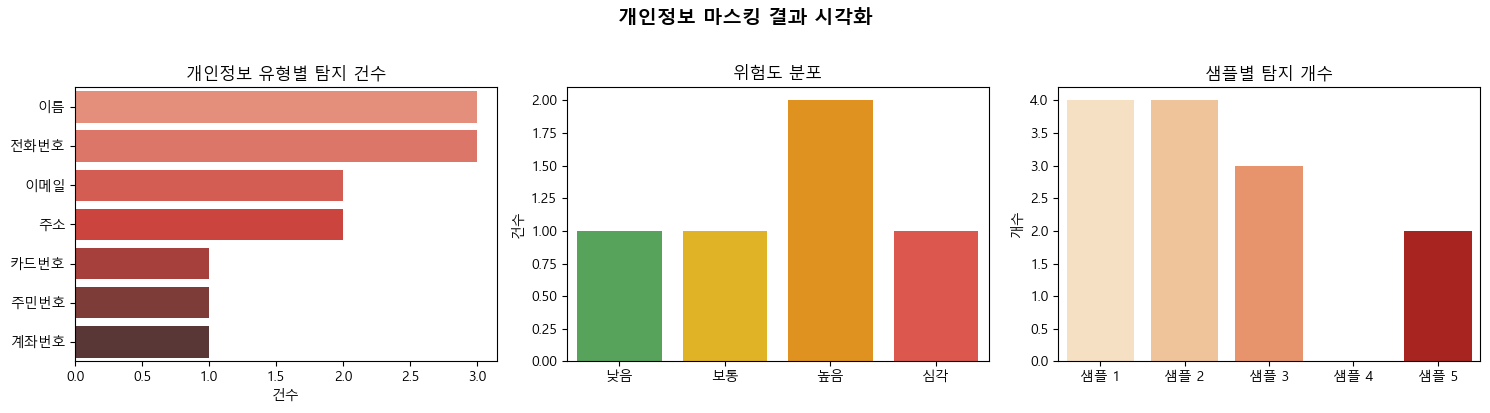

In [6]:
# PII 유형별 탐지 건수 집계 (중첩 리스트를 풀어서 카운트)
pii_type_map = {
    "name": "이름", "phone": "전화번호", "email": "이메일",
    "address": "주소", "id_number": "주민번호", "credit_card": "카드번호",
    "account": "계좌번호", "other": "기타"
}
risk_map = {"low": "낮음", "medium": "보통", "high": "높음", "critical": "심각"}

# 탐지된 PII 항목을 플랫하게 펼침
all_items = []
for row in pii_results:
    for item in row['detected_items']:
        all_items.append({
            'pii_type_kr': pii_type_map.get(item['pii_type'], item['pii_type']),
            'confidence': item['confidence_score']
        })
df_items = pd.DataFrame(all_items)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) PII 유형별 탐지 건수
if not df_items.empty:
    sns.countplot(data=df_items, y='pii_type_kr',
                  order=df_items['pii_type_kr'].value_counts().index,
                  palette='Reds_d', ax=axes[0])
axes[0].set_title('개인정보 유형별 탐지 건수')
axes[0].set_xlabel('건수')
axes[0].set_ylabel('')

# 2) 위험도 분포
df_pii_vis = df_pii.copy()
df_pii_vis['risk_kr'] = df_pii_vis['risk_level'].map(risk_map)
risk_order = ['낮음', '보통', '높음', '심각']
risk_vals = [r for r in risk_order if r in df_pii_vis['risk_kr'].values]
risk_colors = {'낮음': '#4CAF50', '보통': '#FFC107', '높음': '#FF9800', '심각': '#F44336'}
sns.countplot(data=df_pii_vis, x='risk_kr', order=risk_vals,
              palette=[risk_colors[r] for r in risk_vals], ax=axes[1])
axes[1].set_title('위험도 분포')
axes[1].set_xlabel('')
axes[1].set_ylabel('건수')

# 3) 샘플별 탐지 개수
sample_labels = [f'샘플 {i+1}' for i in range(len(df_pii))]
sns.barplot(x=sample_labels, y=df_pii['total_count'].values,
            palette='OrRd', ax=axes[2])
axes[2].set_title('샘플별 탐지 개수')
axes[2].set_xlabel('')
axes[2].set_ylabel('개수')

plt.suptitle('개인정보 마스킹 결과 시각화', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5. 설문조사 데이터 검증 및 표준화

**설문조사 검증 스키마 설계 프로세스**

**1. 비즈니스 질문부터 시작**

**Q: 설문조사 응답으로 무엇을 얻고 싶은가?**

A: 자유형식 설문조사 응답을 분석해서 응답자의 인구통계 정보(나이, 성별, 직업, 소득 등)를 자동으로 추출하고, 데이터 분석을 위해 표준화하며, 응답의 품질을 평가하고 싶다

**2. 필요한 정보 나열**

- **원본 응답 텍스트** : 사용자가 입력한 전체 내용
- **추출된 원본 정보** :
  - 나이: 숫자로 변환 (예: "스물다섯살" => 25)
  - 성별: 남성/여성/불명
  - 직업: 원본 표현 그대로
  - 연소득: 만원 단위 숫자 (예: "3천만원" => 3000)
  - 학력: 원본 표현
  - 거주지역: 시/도 수준
- **표준화 정보 (중첩 구조)** :
  - 연령대: "20대", "30대" 등
  - 직업 대분류: "사무직", "전문직" 등
  - 소득 구간: "3000만원 미만" 등
  - 학력 수준: "고졸", "대졸" 등
  - 지역 분류: "서울", "경기", "광역시", "지방"
- **품질 평가** :
  - 품질 등급: excellent/good/fair/poor
  - 신뢰도 점수: 0.0~1.0
  - 발견된 이슈 목록

**3. Pydantic 스키마 설계 (중첩 구조)**

**메인 스키마: SurveyValidation**

| 필드 | 타입 | 설명 | 제약조건 |
|------|------|------|----------|
| `age` | `Optional[int]` | 나이 | `ge=0, le=150` (없으면 null) |
| `gender` | `Literal[...]` | 성별 | 3가지 고정 값 |
| `occupation` | `Optional[str]` | 직업 | 없으면 null |
| `annual_income` | `Optional[int]` | 연소득 (만원) | `ge=0` (없으면 null) |
| `education` | `Optional[str]` | 학력 | 없으면 null |
| `location` | `Optional[str]` | 거주지역 | 없으면 null |
| `standardized` | `StandardizedInfo` | 표준화 정보 **(중첩)** | - |
| `data_quality` | `Literal[...]` | 품질 등급 | 4가지 고정 값 |
| `confidence_score` | `float` | 신뢰도 | `ge=0.0, le=1.0` |
| `issues_found` | `List[str]` | 발견된 이슈 | `max_length=5` (최대 5개) |

**중첩 스키마: StandardizedInfo**

| 필드 | 타입 | 설명 | 제약조건 |
|------|------|------|----------|
| `age_group` | `Optional[str]` | 연령대 (20대 등) | 없으면 null |
| `job_category` | `Optional[str]` | 직업 대분류 | 없으면 null |
| `income_range` | `Optional[str]` | 소득 구간 | 없으면 null |
| `education_level` | `Optional[str]` | 학력 수준 | 없으면 null |
| `region` | `Optional[str]` | 지역 분류 | 없으면 null |

**설계 포인트:**
- **StandardizedInfo 필드가 모두 Optional인 이유:** 원본 응답에 해당 정보가 없으면 표준화도 불가능하므로, 원본이 null이면 표준화 결과도 null로 처리
- **원본 vs 표준화 분리:** 원본 데이터(age=25)와 분석용 카테고리(age_group="20대")를 분리하면, 원본 데이터 손실 없이 분석 가능

**실습 (1)**
- 중첩 구조를 활용한 설문조사 검증 스키마를 정의합니다.

In [8]:
# =============================================================================
# 설문조사 검증 스키마
# =============================================================================

# 표준화/카테고리화 정보 (중첩 구조)
class StandardizedInfo(BaseModel):
    """
    분석을 위해 원본 데이터를 카테고리화한 표준화 정보
    - 원본: age=25 => 표준화: age_group="20대"
    - 원본: occupation="회사원" => 표준화: job_category="사무직"
    """
    age_group: Optional[str] = Field(
        description="연령대 (10대, 20대, 30대, 40대, 50대, 60대 이상). age 필드에서 자동 매핑"
    )                        
    job_category: Optional[Literal['사무직', '전문직', '자영업', '학생', '무직', '기타']] = Field(
        description="직업 대분류 (사무직: 회사원/직장인, 전문직: 의사/교사/개발자/간호사, 자영업, 학생, 무직, 기타: 프리랜서 등)"
    )
    income_range: Optional[str] = Field(
        description="소득 구간 (3000만원 미만, 3000-5000만원, 5000-7000만원, 7000만원 이상)"
    )
    education_level: Optional[str] = Field(
        description="학력 (고졸 이하, 대졸, 대학원졸)"
    )
    region: Optional[str] = Field(
        description="지역 (서울, 경기, 광역시: 부산/대구/인천 등, 지방: 충청/경상/전라/강원/제주)"
    )

# 메인 스키마: 설문조사 검증 결과
class SurveyValidation(BaseModel):
    """
    설문조사 응답을 검증하고 표준화한 최종 결과
    - 원본 정보 추출 (age, gender, occupation 등)
    - 표준화 정보 생성 (age_group, job_category 등)
    - 데이터 품질 평가 (quality, confidence, issues)
    """

    # =========================================================================
    # 추출된 원본 정보 (응답자가 입력한 그대로)
    # =========================================================================
    age: Optional[int] = Field(
        ge=0, le=150,
        description=(
            "나이 (숫자로 변환). "
            "정확한 표현: '스물다섯살'=>25, '서른'=>30. "
            "범위 표현은 대표값으로 추정: '20대 후반'=>28, '30대 초반'=>32, '40대'=>45. "
            "전혀 파악 불가능한 경우만 null"
        )
    )
    age_is_estimated: bool = Field(
        description="나이가 추정값인지 여부. '20대 후반', '40대 초반'처럼 범위에서 추정한 경우 true, '25살'처럼 정확한 경우 false"
    )
    gender: Literal["male", "female", "unknown"] = Field(
        description="성별. male: 남자/남성, female: 여자/여성, unknown: 불명확하거나 언급 없음"
    )
    occupation: Optional[str] = Field(
        description="직업 (원본 표현 그대로 기록. '회사원', '개발자' 등. 무직이면 '무직', 언급 없으면 null)"
    )
    annual_income: Optional[int] = Field(
        ge=0,
        description="연소득 만원 단위 정수. '3000만원'=>3000, '3천5백'=>3500, '5천만원'=>5000. 금액 파악 불가시 null"
    )
    education: Optional[str] = Field(
        description="학력 (원본 표현 그대로 기록. '대졸', '석사과정', '고졸' 등. 언급 없으면 null)"
    )
    location: Optional[str] = Field(
        description="거주지역 (시/도 수준으로 정규화. '서울 강남'=>'서울', '경기도 수원'=>'경기도')"
    )

    # =========================================================================
    # 데이터 분석을 위한 표준화 정보 (중첩 구조)
    # =========================================================================
    standardized: StandardizedInfo = Field(
        description="원본 정보를 분석 가능한 카테고리로 변환한 표준화 데이터"
    )

    # =========================================================================
    # 데이터 품질 검증 결과
    # =========================================================================
    data_quality: Literal["excellent", "good", "fair", "poor"] = Field(
        description=(
            "추출 필드 신뢰도 기반 품질 등급. "
            "excellent: 5개 이상 필드를 명확히 추출, "
            "good: 3-4개 필드 신뢰 가능, "
            "fair: 2개 필드만 신뢰 가능, "
            "poor: 1개 이하 또는 대부분 불확실"
        )
    )
    confidence_score: float = Field(
        ge=0.0, le=1.0,
        description="전체 추출 결과의 신뢰도 (0.0~1.0). 명확한 정보가 많을수록 높음"
    )
    issues_found: List[str] = Field(
        description="발견된 문제점 목록 (예: '나이가 범위 표현이라 추정값 사용', '연소득 정보 불명확', '성별 미기재')",
        max_length=5
    )

print("설문조사 검증 스키마 정의 완료")

설문조사 검증 스키마 정의 완료


In [11]:
SurveyValidation.model_json_schema()

{'$defs': {'StandardizedInfo': {'description': '분석을 위해 원본 데이터를 카테고리화한 표준화 정보\n- 원본: age=25 => 표준화: age_group="20대"\n- 원본: occupation="회사원" => 표준화: job_category="사무직"',
   'properties': {'age_group': {'anyOf': [{'type': 'string'},
      {'type': 'null'}],
     'description': '연령대 (10대, 20대, 30대, 40대, 50대, 60대 이상). age 필드에서 자동 매핑',
     'title': 'Age Group'},
    'job_category': {'anyOf': [{'enum': ['사무직',
        '전문직',
        '자영업',
        '학생',
        '무직',
        '기타'],
       'type': 'string'},
      {'type': 'null'}],
     'description': '직업 대분류 (사무직: 회사원/직장인, 전문직: 의사/교사/개발자/간호사, 자영업, 학생, 무직, 기타: 프리랜서 등)',
     'title': 'Job Category'},
    'income_range': {'anyOf': [{'type': 'string'}, {'type': 'null'}],
     'description': '소득 구간 (3000만원 미만, 3000-5000만원, 5000-7000만원, 7000만원 이상)',
     'title': 'Income Range'},
    'education_level': {'anyOf': [{'type': 'string'}, {'type': 'null'}],
     'description': '학력 (고졸 이하, 대졸, 대학원졸)',
     'title': 'Education Level'},
    'region': {'a

**실습 (2)**
- `Agent(output_type=SurveyValidation)`로 중첩 구조의 구조화된 출력을 받습니다.

In [12]:
# =============================================================================
# 샘플 설문조사 응답 데이터 (비정형 형태)
# =============================================================================

# 실제 설문조사에서 수집되는 다양한 형식의 응답 예시
# - 한글/영어 혼용, 띄어쓰기 불규칙, 단위 표현 다양, 구어체 표현 포함
survey_responses = [
    "나이: 스물다섯살, 성별: 남자, 직업: 회사원, 연봉: 3000만원정도, 학력: 대졸, 지역: 서울",
    "25세 여성 개발자입니다. 연소득 3천5백. 석사과정 중이고 경기도 거주",
    "thirty years old, male, teacher, 2800만원, 학사졸업, 부산시",
    "나이 모름, 직업: 프리랜서, 돈: 많이벌어요 ㅋㅋ, 서울 강남 살아요",
    "28살 여자 간호사 연봉 3200 대학졸업 대구",
    "19세, 학생, 무직, 용돈 받아서 살아요, 부모님과 거주 인천",
    "40대 초반 남성 자영업자 연수입 5000만원 고졸 충청도"
]

# =============================================================================
# 시스템 프롬프트 정의
# - 추출/표준화/품질 기준은 스키마 description에 포함
# - 여기서는 스키마로 표현할 수 없는 행동 지시만 작성합니다
# =============================================================================

survey_system_prompt = """
당신은 설문조사 데이터 품질 관리 전문가입니다.
비정형 텍스트 응답을 구조화된 데이터로 변환하고 품질을 평가하세요.
불확실한 정보는 null로 처리하세요.
"""

# =============================================================================
# PydanticAI Agent 생성 및 설문조사 검증 실행
# =============================================================================

# Agent 생성 - output_type으로 중첩 구조 구조화된 출력 강제
survey_agent = Agent(
    model_id,
    output_type=SurveyValidation,
    system_prompt=survey_system_prompt,
)

# 매개변수 설정 - 낮은 temperature로 일관된 추출
survey_settings = GoogleModelSettings(temperature=0.1)

print("설문조사 데이터 검증 시작...")
print("=" * 80)

# 검증 결과를 저장할 리스트
validated_surveys = []

# 각 설문조사 응답을 순회하며 검증 및 표준화
for i, response in enumerate(survey_responses, 1):
    print(f'[응답 {i}]: "{response}"')

    # LLM에 전달할 프롬프트 구성
    prompt = f"다음 설문조사 응답을 검증하고 표준화해주세요:\n\n{response}"

    # PydanticAI Agent 실행 (비동기)
    result = await survey_agent.run(prompt, model_settings=survey_settings)

    # result.output => SurveyValidation 객체 (자동 파싱)
    output = result.output

    # 딕셔너리로 변환 + 원본 텍스트는 코드에서 합치기 (출력 토큰 절약)
    row = {"original_response": response, **output.model_dump()}
    validated_surveys.append(row)

    # 검증 결과 출력: 원본 정보 vs 표준화 정보 비교
    age_display = f"{output.age}{'(추정)' if output.age_is_estimated else ''}" if output.age else "미상"
    print(f"  - 원본정보: 나이={age_display}, 성별={output.gender}, 직업={output.occupation}")
    print(f"  - 표준화: {output.standardized.age_group}, {output.standardized.job_category}, {output.standardized.income_range}")
    print(f"  - 품질: {output.data_quality} (신뢰도: {output.confidence_score:.2f})")

    # 이슈가 발견된 경우에만 출력
    if output.issues_found:
        print(f"  [이슈]: {', '.join(output.issues_found)}")

    time.sleep(API_DELAY)

# 전체 처리 결과 요약
print()
print("=" * 80)
print(f"총 {len(validated_surveys)}개 응답 검증 완료")

설문조사 데이터 검증 시작...
[응답 1]: "나이: 스물다섯살, 성별: 남자, 직업: 회사원, 연봉: 3000만원정도, 학력: 대졸, 지역: 서울"
  - 원본정보: 나이=25, 성별=male, 직업=회사원
  - 표준화: 20대, 사무직, 3000-5000만원
  - 품질: excellent (신뢰도: 1.00)
[응답 2]: "25세 여성 개발자입니다. 연소득 3천5백. 석사과정 중이고 경기도 거주"
  - 원본정보: 나이=25, 성별=female, 직업=개발자
  - 표준화: 20대, 전문직, 3000-5000만원
  - 품질: excellent (신뢰도: 1.00)
[응답 3]: "thirty years old, male, teacher, 2800만원, 학사졸업, 부산시"
  - 원본정보: 나이=30, 성별=male, 직업=teacher
  - 표준화: 30대, 전문직, 3000만원 미만
  - 품질: excellent (신뢰도: 1.00)
[응답 4]: "나이 모름, 직업: 프리랜서, 돈: 많이벌어요 ㅋㅋ, 서울 강남 살아요"
  - 원본정보: 나이=미상, 성별=unknown, 직업=프리랜서
  - 표준화: None, 기타, None
  - 품질: poor (신뢰도: 0.40)
  [이슈]: 나이 정보 없음, 연소득 정보 불명확(주관적 표현), 성별 정보 없음, 학력 정보 없음
[응답 5]: "28살 여자 간호사 연봉 3200 대학졸업 대구"
  - 원본정보: 나이=28, 성별=female, 직업=간호사
  - 표준화: 20대, 전문직, 3000-5000만원
  - 품질: excellent (신뢰도: 1.00)
[응답 6]: "19세, 학생, 무직, 용돈 받아서 살아요, 부모님과 거주 인천"
  - 원본정보: 나이=19, 성별=unknown, 직업=학생
  - 표준화: 10대, 학생, 3000만원 미만
  - 품질: good (신뢰도: 0.90)
  [이슈]: 성별 정보 없음, 연소득 정보 없음 (용돈 생활), 학력 정보 없음
[응답 7]: "40

In [13]:
pprint(validated_surveys)

[{'age': 25,
  'age_is_estimated': False,
  'annual_income': 3000,
  'confidence_score': 1.0,
  'data_quality': 'excellent',
  'education': '대졸',
  'gender': 'male',
  'issues_found': [],
  'location': '서울',
  'occupation': '회사원',
  'original_response': '나이: 스물다섯살, 성별: 남자, 직업: 회사원, 연봉: 3000만원정도, 학력: 대졸, 지역: '
                       '서울',
  'standardized': {'age_group': '20대',
                   'education_level': '대졸',
                   'income_range': '3000-5000만원',
                   'job_category': '사무직',
                   'region': '서울'}},
 {'age': 25,
  'age_is_estimated': False,
  'annual_income': 3500,
  'confidence_score': 1.0,
  'data_quality': 'excellent',
  'education': '석사과정',
  'gender': 'female',
  'issues_found': [],
  'location': '경기도',
  'occupation': '개발자',
  'original_response': '25세 여성 개발자입니다. 연소득 3천5백. 석사과정 중이고 경기도 거주',
  'standardized': {'age_group': '20대',
                   'education_level': '대학원졸',
                   'income_range': '3000-5000만원',
          

**실습 (3)**
- 검증 결과를 DataFrame 표 형태로 확인합니다.

In [14]:
import pandas as pd

# 처리 결과를 DataFrame으로 변환
df_surveys = pd.DataFrame(validated_surveys)
print("=== 설문조사 검증 결과 (DataFrame) ===")
print()
display(df_surveys.head())

=== 설문조사 검증 결과 (DataFrame) ===



,original_response,age,age_is_estimated,gender,occupation,annual_income,education,location,standardized,data_quality,confidence_score,issues_found
0,"나이: 스물다섯살, 성별: 남자, 직업: 회사원, 연봉: 3000만원정도, 학력: ...",25.0,False,male,회사원,3000.0,대졸,서울,"{'age_group': '20대', 'job_category': '사무직', 'i...",excellent,1.0,[]
1,25세 여성 개발자입니다. 연소득 3천5백. 석사과정 중이고 경기도 거주,25.0,False,female,개발자,3500.0,석사과정,경기도,"{'age_group': '20대', 'job_category': '전문직', 'i...",excellent,1.0,[]
2,"thirty years old, male, teacher, 2800만원, 학사졸업,...",30.0,False,male,teacher,2800.0,학사졸업,부산,"{'age_group': '30대', 'job_category': '전문직', 'i...",excellent,1.0,[]
3,"나이 모름, 직업: 프리랜서, 돈: 많이벌어요 ㅋㅋ, 서울 강남 살아요",NaN,False,unknown,프리랜서,NaN,NaN,서울,"{'age_group': None, 'job_category': '기타', 'inc...",poor,0.4,"[나이 정보 없음, 연소득 정보 불명확(주관적 표현), 성별 정보 없음, 학력 정보..."
4,28살 여자 간호사 연봉 3200 대학졸업 대구,28.0,False,female,간호사,3200.0,대학졸업,대구,"{'age_group': '20대', 'job_category': '전문직', 'i...",excellent,1.0,[]


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_24992\3231560059.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_survey_vis, x='gender_kr', order=gender_vals,
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_24992\3231560059.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_survey_vis, x='age_group',
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_24992\3231560059.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_survey_vis, y='job_category',


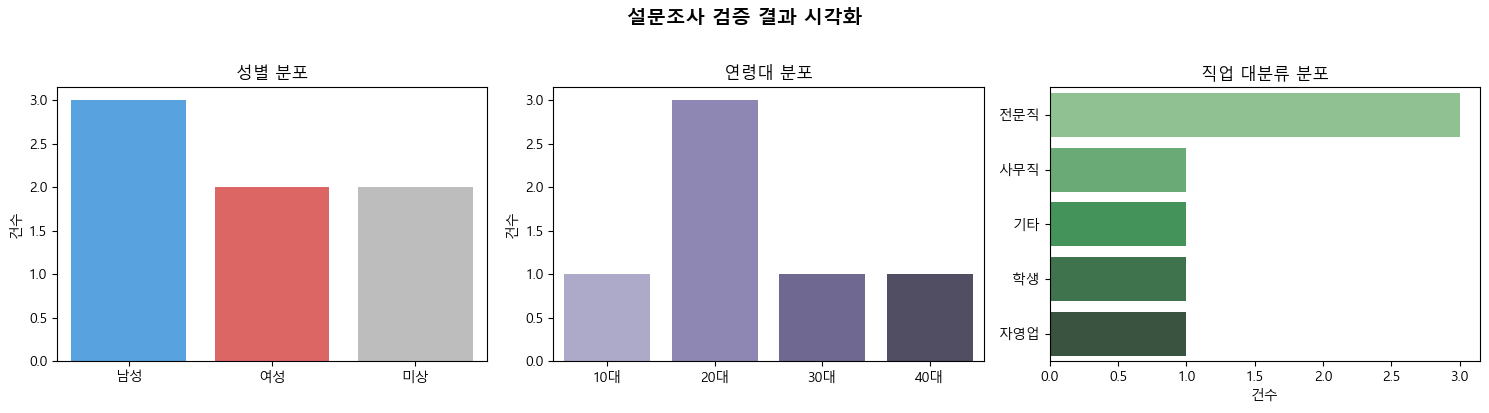

In [15]:
# 표준화 정보를 플랫하게 펼침
df_survey_vis = df_surveys.copy()
std_df = pd.json_normalize(df_surveys['standardized'])
df_survey_vis = pd.concat([df_survey_vis.drop(columns=['standardized']), std_df], axis=1)

# 성별 한글 매핑
gender_map = {"male": "남성", "female": "여성", "unknown": "미상"}
df_survey_vis['gender_kr'] = df_survey_vis['gender'].map(gender_map)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) 성별 분포
gender_order = ['남성', '여성', '미상']
gender_vals = [g for g in gender_order if g in df_survey_vis['gender_kr'].values]
gender_colors = {'남성': '#42A5F5', '여성': '#EF5350', '미상': '#BDBDBD'}
sns.countplot(data=df_survey_vis, x='gender_kr', order=gender_vals,
              palette=[gender_colors[g] for g in gender_vals], ax=axes[0])
axes[0].set_title('성별 분포')
axes[0].set_xlabel('')
axes[0].set_ylabel('건수')

# 2) 연령대 분포
age_data = df_survey_vis['age_group'].dropna()
if not age_data.empty:
    sns.countplot(data=df_survey_vis, x='age_group',
                  order=sorted(age_data.unique()),
                  palette='Purples_d', ax=axes[1])
axes[1].set_title('연령대 분포')
axes[1].set_xlabel('')
axes[1].set_ylabel('건수')

# 3) 직업 대분류 분포
job_data = df_survey_vis['job_category'].dropna()
if not job_data.empty:
    sns.countplot(data=df_survey_vis, y='job_category',
                  order=job_data.value_counts().index,
                  palette='Greens_d', ax=axes[2])
axes[2].set_title('직업 대분류 분포')
axes[2].set_xlabel('건수')
axes[2].set_ylabel('')

plt.suptitle('설문조사 검증 결과 시각화', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()